# 实验六：minGPT-2

**课程**：深度学习导论  
**核心交付物**：可运行的 GPT-2 级别 Transformer 解码器 + 权重对齐验证 + 下游微调 + 自回归生成

**AI使用说明**：本实验允许并鼓励负责任地使用 AI 辅助理解、查文档、调试、润色表达。不设抽查答辩、不禁止长段 AI 生成。

## 1. 环境与依赖

In [1]:
import random, math, os, urllib.request
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')
os.environ.setdefault('HF_HUB_DISABLE_XET', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

if torch.cuda.is_available():
    # GPT-2 ??????????? TF32 ?????????
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'?????{device}')
if device.type == 'cuda':
    print(f'CUDA ???{torch.cuda.get_device_name(0)}')

try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
except Exception as e:
    print(f'transformers ?????????{e}')
    GPT2LMHeadModel = GPT2Tokenizer = None

try:
    from datasets import load_dataset
except Exception as e:
    print(f'datasets ?????????{e}')
    load_dataset = None

?????cuda
CUDA ???NVIDIA GeForce RTX 4070 Laptop GPU


c:\Users\njb18\miniconda3\envs\deeplearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 数学基础与推导

本节集中给出 Lab 6 所需的全部数学工具。

### 2.1 GPT-2 架构与 Lab 5 的差分

| 维度 | Lab 5（Post-LN Encoder） | Lab 6（Pre-LN Decoder） |
|------|--------------------------|-------------------------|
| LayerNorm 位置 | 残差相加**之后** | 残差相加**之前** |
| 位置编码 | Sinusoidal（固定） | Learned（可学习） |
| 激活函数 | ReLU | GELU |

**Pre-LN 残差路径**（$l$ 为层索引，$\mathbf{x}$ 为输入）：

$$\mathbf{x}' = \mathbf{x} + \text{MHA}(\text{LN}(\mathbf{x}))$$

$$\mathbf{x}'' = \mathbf{x}' + \text{FFN}(\text{LN}(\mathbf{x}'))$$

**Post-LN 残差路径**（Lab 5 形式，供对比）：

$$\mathbf{x}' = \text{LN}(\mathbf{x} + \text{MHA}(\mathbf{x}))$$

### 2.2 自回归语言建模的概率基础

因果掩码下的条件概率链式分解：

$$P(w_{1:L}) = \prod_{t=1}^{L} P(w_t \mid w_{<t})$$

训练目标为最小化交叉熵损失：

$$\mathcal{L}_{LM} = -\frac{1}{L} \sum_{t=1}^{L} \log P(w_t \mid w_{<t}; \theta)$$

**Teacher Forcing**：训练时以真实 token $w_{<t}$ 作为上下文；推理时以模型自身生成的 token 作为上下文（存在训练-推理分布偏移）。

### 2.3 采样策略的数学定义

设第 $t$ 步的 logits 向量为 $\mathbf{z} \in \mathbb{R}^{|V|}$。

**Greedy Decoding**：$w_t = \arg\max_{w} P(w \mid w_{<t})$

**Temperature Sampling**（$\tau > 0$）：
$$P'(w) = \frac{\exp(z_w / \tau)}{\sum_j \exp(z_j / \tau)}$$
$\tau \to 0$ 退化为 Greedy；$\tau \to \infty$ 趋向均匀分布。

**Top-k Sampling**：保留概率最高的 $k$ 个候选，其余置 $-\infty$，再重新归一化。

**Top-p（Nucleus）Sampling**：按概率降序排列，保留累积概率恰好超过 $p$ 的最小候选集，再重新归一化。

### 2.4 Decoder-only 做判别任务的归纳偏置分析

**【请填写】** 在下方补全三个层面的论证：

$$
\begin{aligned}
1.\; &\text{注意力方向性：} \quad \dots \\
2.\; &\text{预训练目标错配：} \quad \dots \\
3.\; &\text{表征提取位置非对称性：} \quad \dots
\end{aligned}
$$

Decoder-only ??????????? $t$ ????? $w_{<t}$?????????????????????????????????????????????????????????????????????BERT ? Encoder self-attention ????? token ??????????? GPT-2 ??? token ???????????????? token ???????????????????????????????????????????????????????????

GPT-2 ??????? next-token prediction???? $P(w_t \mid w_{<t})$?????????????????????????????????????????????????????????????????????????????????????BERT ? masked language modeling ????????????????????????????????????????????

??????????????GPT-2 ????????? token ??????????????????????? token?????????????????????????? padding?????? token ?????????????????????BERT ?????? `[CLS]` ??????????????????? token ????????????????????????

## 3. GPT-2 架构实现

### 3.1 Learned Positional Embedding

GPT-2 使用可学习的位置编码，而非 Lab 5 中的 Sinusoidal PE。
实现 `nn.Embedding(max_position, d_model)` 的位置编码层，`forward` 中根据序列长度切片并返回位置嵌入。

**【请填写】**：在下方围栏内实现 `LearnedPositionalEmbedding` 类。

In [2]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_position: int, d_model: int):
        super().__init__()
        # GPT-2 ????????????? (max_position, d_model)?
        self.embedding = nn.Embedding(max_position, d_model)

    def forward(self, seq_len: int) -> 'torch.Tensor':
        if seq_len > self.embedding.num_embeddings:
            raise ValueError(
                f'seq_len={seq_len} exceeds max_position={self.embedding.num_embeddings}'
            )
        positions = torch.arange(seq_len, device=self.embedding.weight.device)
        return self.embedding(positions)

In [3]:
# 【维度自检】如果此 cell 报错，说明你的实现张量形状错误
_pe = LearnedPositionalEmbedding(max_position=1024, d_model=768)
_out = _pe(10)
assert _out.shape == (10, 768), f'shape error: {_out.shape}'
print('=> LearnedPositionalEmbedding 维度校验通过！')


=> LearnedPositionalEmbedding 维度校验通过！


### 3.2 因果掩码

**【请填写】**：在下方围栏内实现 `make_causal_mask` 函数。

In [4]:
def make_causal_mask(seq_len: int, device: 'torch.device') -> 'torch.Tensor':
    """???? (1, 1, seq_len, seq_len) ????????True ??????"""
    mask = torch.triu(
        torch.ones(seq_len, seq_len, dtype=torch.bool, device=device),
        diagonal=1,
    )
    return mask.view(1, 1, seq_len, seq_len)

In [5]:
# 【维度自检】
_mask = make_causal_mask(4, device=torch.device('cpu'))
assert _mask.shape == (1, 1, 4, 4), f'shape error: {_mask.shape}'
assert _mask[0, 0, 0, 1].item() == True,  '位置 (0,1) 应被遮蔽'
assert _mask[0, 0, 1, 0].item() == False, '位置 (1,0) 不应被遮蔽'
print('=> make_causal_mask 维度与逻辑校验通过！')


=> make_causal_mask 维度与逻辑校验通过！


### 3.3 带因果掩码的多头自注意力

只需完成 Multi-Head 的 split/merge 部分。

**【请填写】**：在下方围栏内补全 `MultiHeadSelfAttention.forward` 方法。

In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x: 'torch.Tensor', mask: 'torch.Tensor' = None) -> 'torch.Tensor':
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)

        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        attn_weights = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_weights = attn_weights.masked_fill(mask, torch.finfo(attn_weights.dtype).min)

        attn_probs = F.softmax(attn_weights, dim=-1)
        attn_probs = self.attn_drop(attn_probs)
        out = attn_probs @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.c_proj(out)
        out = self.resid_drop(out)
        return out

In [7]:
# 【维度自检】
_mha = MultiHeadSelfAttention(d_model=64, n_heads=4)
_x = torch.randn(2, 8, 64)
_mask = make_causal_mask(8, device=torch.device('cpu'))
_out = _mha(_x, _mask)
assert _out.shape == (2, 8, 64), f'shape error: {_out.shape}'
print('=> MultiHeadSelfAttention 维度校验通过！')


=> MultiHeadSelfAttention 维度校验通过！


### 3.4 GPT-2 Block（Pre-LN）

这是 GPT-2 与 Lab 5 Post-LN TransformerBlock 的核心区别。
只需在 `forward` 中实现正确的 Pre-LN 残差路径。
注意 FFN 使用 GELU 而非 ReLU。

**【请填写】**：在下方围栏内实现 `GPT2Block.forward` 方法。

In [8]:
class GPT2Block(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(approximate='tanh'),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: 'torch.Tensor', mask: 'torch.Tensor' = None) -> 'torch.Tensor':
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.ffn(self.ln2(x))
        return x

In [9]:
# 【维度自检】
_blk = GPT2Block(d_model=64, n_heads=4, d_ff=256)
_x = torch.randn(2, 8, 64)
_mask = make_causal_mask(8, device=torch.device('cpu'))
_out = _blk(_x, _mask)
assert _out.shape == (2, 8, 64), f'shape error: {_out.shape}'
print('=> GPT2Block 维度校验通过！')


=> GPT2Block 维度校验通过！


### 3.5 完整 minGPT-2 模型组装

将 Token Embedding、Learned Positional Embedding、多层 GPT-2 Block、最终 LayerNorm 和 LM Head 组装为完整模型。

**【请填写】**：在下方围栏内实现 `minGPT2.forward` 方法。

In [10]:
class minGPT2(nn.Module):
    def __init__(self, vocab_size: int, max_position: int, d_model: int,
                 n_heads: int, n_layers: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = LearnedPositionalEmbedding(max_position, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            GPT2Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def hidden_states(self, input_ids: 'torch.Tensor') -> 'torch.Tensor':
        B, T = input_ids.shape
        tok = self.tok_emb(input_ids)
        pos = self.pos_emb(T).unsqueeze(0)
        x = self.drop(tok + pos)
        mask = make_causal_mask(T, device=input_ids.device)
        for block in self.blocks:
            x = block(x, mask)
        return self.ln_f(x)

    def forward(self, input_ids: 'torch.Tensor') -> 'torch.Tensor':
        """input_ids: (B, T) -> logits: (B, T, vocab_size)"""
        h = self.hidden_states(input_ids)
        logits = self.lm_head(h)
        return logits

In [11]:
# 【维度自检】
_cfg = dict(vocab_size=50257, max_position=1024, d_model=64,
            n_heads=4, n_layers=2, d_ff=256)
_model = minGPT2(**_cfg)
_ids = torch.randint(0, 50257, (2, 16))
_logits = _model(_ids)
assert _logits.shape == (2, 16, 50257), f'shape error: {_logits.shape}'
print('=> minGPT2 维度校验通过！')


=> minGPT2 维度校验通过！


## 4. 权重加载与数值对齐验证

### 4.1 HuggingFace 权重映射

HuggingFace GPT-2 使用 `Conv1D`，权重形状为 `(in, out)`，与 PyTorch `nn.Linear` 的 `(out, in)` 相反，加载时需要转置。

| HuggingFace 键 | 本实现键 | 处理方式 |
|----------------|----------|----------|
| `transformer.wte.weight` | `tok_emb.weight` | 直接复制 |
| `transformer.wpe.weight` | `pos_emb.embedding.weight` | 直接复制 |
| `transformer.h.{i}.attn.c_attn.weight` | `blocks.{i}.attn.c_attn.weight` | **转置** |

**其余映射请自行通过 `hf_model.state_dict().keys()` 探索补全。**
提示：共需映射约 150 个参数张量（12 层 × 每层 12 个参数 + 全局 6 个）。

**【请填写】**：在下方围栏内实现 `load_hf_weights` 函数。

In [12]:
# ?????? HuggingFace ?????????????????

def load_hf_gpt2_model(model_name='gpt2'):
    """?? HuggingFace GPT-2?????? eager attention ???????"""
    if GPT2LMHeadModel is None:
        return None
    try:
        return GPT2LMHeadModel.from_pretrained(model_name, attn_implementation='eager')
    except (TypeError, ValueError):
        return GPT2LMHeadModel.from_pretrained(model_name)

if GPT2LMHeadModel is not None:
    hf_model_tmp = load_hf_gpt2_model('gpt2')
    print("=== HuggingFace GPT-2 ????? 20 ??===")
    for i, k in enumerate(hf_model_tmp.state_dict().keys()):
        if i >= 20: break
        print(f"  {k}: {hf_model_tmp.state_dict()[k].shape}")

    print("\n=== ??? minGPT2 ????? 20 ??===")
    _tmp = minGPT2(vocab_size=50257, max_position=1024, d_model=768,
                   n_heads=12, n_layers=12, d_ff=3072)
    for i, (k, v) in enumerate(_tmp.named_parameters()):
        if i >= 20: break
        print(f"  {k}: {v.shape}")
    del _tmp, hf_model_tmp
    if device.type == 'cuda':
        torch.cuda.empty_cache()

=== HuggingFace GPT-2 ????? 20 ??===
  transformer.wte.weight: torch.Size([50257, 768])
  transformer.wpe.weight: torch.Size([1024, 768])
  transformer.h.0.ln_1.weight: torch.Size([768])
  transformer.h.0.ln_1.bias: torch.Size([768])
  transformer.h.0.attn.c_attn.weight: torch.Size([768, 2304])
  transformer.h.0.attn.c_attn.bias: torch.Size([2304])
  transformer.h.0.attn.c_proj.weight: torch.Size([768, 768])
  transformer.h.0.attn.c_proj.bias: torch.Size([768])
  transformer.h.0.ln_2.weight: torch.Size([768])
  transformer.h.0.ln_2.bias: torch.Size([768])
  transformer.h.0.mlp.c_fc.weight: torch.Size([768, 3072])
  transformer.h.0.mlp.c_fc.bias: torch.Size([3072])
  transformer.h.0.mlp.c_proj.weight: torch.Size([3072, 768])
  transformer.h.0.mlp.c_proj.bias: torch.Size([768])
  transformer.h.1.ln_1.weight: torch.Size([768])
  transformer.h.1.ln_1.bias: torch.Size([768])
  transformer.h.1.attn.c_attn.weight: torch.Size([768, 2304])
  transformer.h.1.attn.c_attn.bias: torch.Size([2304])


  tok_emb.weight: torch.Size([50257, 768])
  pos_emb.embedding.weight: torch.Size([1024, 768])
  blocks.0.ln1.weight: torch.Size([768])
  blocks.0.ln1.bias: torch.Size([768])
  blocks.0.attn.c_attn.weight: torch.Size([2304, 768])
  blocks.0.attn.c_attn.bias: torch.Size([2304])
  blocks.0.attn.c_proj.weight: torch.Size([768, 768])
  blocks.0.attn.c_proj.bias: torch.Size([768])
  blocks.0.ln2.weight: torch.Size([768])
  blocks.0.ln2.bias: torch.Size([768])
  blocks.0.ffn.0.weight: torch.Size([3072, 768])
  blocks.0.ffn.0.bias: torch.Size([3072])
  blocks.0.ffn.2.weight: torch.Size([768, 3072])
  blocks.0.ffn.2.bias: torch.Size([768])
  blocks.1.ln1.weight: torch.Size([768])
  blocks.1.ln1.bias: torch.Size([768])
  blocks.1.attn.c_attn.weight: torch.Size([2304, 768])
  blocks.1.attn.c_attn.bias: torch.Size([2304])
  blocks.1.attn.c_proj.weight: torch.Size([768, 768])
  blocks.1.attn.c_proj.bias: torch.Size([768])


In [13]:
def load_hf_weights(model: 'minGPT2', hf_model) -> None:
    """? HuggingFace GPT2LMHeadModel ?????? minGPT2 ????"""
    hf_sd = hf_model.state_dict()
    n_layers = len(model.blocks)

    def copy_param(param, value, name: str, transpose: bool = False):
        if transpose:
            value = value.t()
        if tuple(param.shape) != tuple(value.shape):
            raise ValueError(f'{name} shape mismatch: model {tuple(param.shape)} vs hf {tuple(value.shape)}')
        param.copy_(value.to(device=param.device, dtype=param.dtype))

    with torch.no_grad():
        copy_param(model.tok_emb.weight, hf_sd['transformer.wte.weight'], 'tok_emb.weight')
        copy_param(model.pos_emb.embedding.weight, hf_sd['transformer.wpe.weight'], 'pos_emb.embedding.weight')
        copy_param(model.ln_f.weight, hf_sd['transformer.ln_f.weight'], 'ln_f.weight')
        copy_param(model.ln_f.bias, hf_sd['transformer.ln_f.bias'], 'ln_f.bias')
        copy_param(model.lm_head.weight, hf_sd['lm_head.weight'], 'lm_head.weight')

        for i in range(n_layers):
            block = model.blocks[i]
            prefix = f'transformer.h.{i}'
            copy_param(block.ln1.weight, hf_sd[f'{prefix}.ln_1.weight'], f'blocks.{i}.ln1.weight')
            copy_param(block.ln1.bias, hf_sd[f'{prefix}.ln_1.bias'], f'blocks.{i}.ln1.bias')
            copy_param(block.attn.c_attn.weight, hf_sd[f'{prefix}.attn.c_attn.weight'], f'blocks.{i}.attn.c_attn.weight', transpose=True)
            copy_param(block.attn.c_attn.bias, hf_sd[f'{prefix}.attn.c_attn.bias'], f'blocks.{i}.attn.c_attn.bias')
            copy_param(block.attn.c_proj.weight, hf_sd[f'{prefix}.attn.c_proj.weight'], f'blocks.{i}.attn.c_proj.weight', transpose=True)
            copy_param(block.attn.c_proj.bias, hf_sd[f'{prefix}.attn.c_proj.bias'], f'blocks.{i}.attn.c_proj.bias')
            copy_param(block.ln2.weight, hf_sd[f'{prefix}.ln_2.weight'], f'blocks.{i}.ln2.weight')
            copy_param(block.ln2.bias, hf_sd[f'{prefix}.ln_2.bias'], f'blocks.{i}.ln2.bias')
            copy_param(block.ffn[0].weight, hf_sd[f'{prefix}.mlp.c_fc.weight'], f'blocks.{i}.ffn.0.weight', transpose=True)
            copy_param(block.ffn[0].bias, hf_sd[f'{prefix}.mlp.c_fc.bias'], f'blocks.{i}.ffn.0.bias')
            copy_param(block.ffn[2].weight, hf_sd[f'{prefix}.mlp.c_proj.weight'], f'blocks.{i}.ffn.2.weight', transpose=True)
            copy_param(block.ffn[2].bias, hf_sd[f'{prefix}.mlp.c_proj.bias'], f'blocks.{i}.ffn.2.bias')


def build_pretrained_mingpt2(dropout: float = 0.0, target_device=device):
    hf = load_hf_gpt2_model('gpt2')
    hf.eval()
    model = minGPT2(
        vocab_size=50257, max_position=1024, d_model=768,
        n_heads=12, n_layers=12, d_ff=3072, dropout=dropout
    )
    load_hf_weights(model, hf)
    model.to(target_device).eval()
    return model, hf

### 4.2 前向数值对齐验证

In [14]:
if GPT2LMHeadModel is not None:
    hf_model = load_hf_gpt2_model('gpt2').to(device)
    hf_model.eval()

    my_model = minGPT2(
        vocab_size=50257, max_position=1024, d_model=768,
        n_heads=12, n_layers=12, d_ff=3072, dropout=0.0
    ).to(device)
    load_hf_weights(my_model, hf_model)
    my_model.eval()

    test_ids = torch.randint(0, 50257, (1, 16), device=device)
    with torch.no_grad():
        my_logits = my_model(test_ids)
        hf_logits = hf_model(test_ids).logits

    max_err = (my_logits - hf_logits).abs().max().item()
    print(f'???????{max_err:.2e}')
    assert max_err < 1e-4, f'????????? {max_err:.2e} ???? 1e-4'
    print('=> ?????????')

    # ????? HuggingFace state_dict ??????? CPU ??? CUDA ???
    hf_model.to('cpu')
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('?????????GPT2LMHeadModel ???')

???????6.87e-05
=> ?????????


**【请填写】** 在下方 code cell 中绘制 logits 对齐误差的直方图，并标注最大绝对误差。

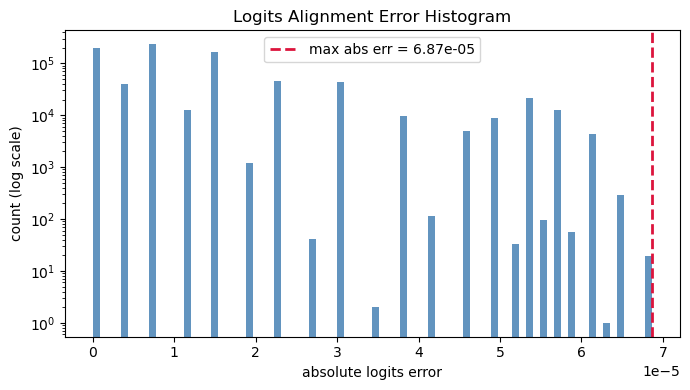

In [15]:
# ==========================
# ??????? logits ???????
# ==========================
if 'my_logits' in globals() and 'hf_logits' in globals():
    errors = (my_logits - hf_logits).detach().abs().cpu().flatten().numpy()
    max_abs_err = float(errors.max())

    plt.figure(figsize=(7, 4))
    plt.hist(errors, bins=80, color='steelblue', alpha=0.85)
    plt.axvline(max_abs_err, color='crimson', linestyle='--', linewidth=2,
                label=f'max abs err = {max_abs_err:.2e}')
    plt.yscale('log')
    plt.xlabel('absolute logits error')
    plt.ylabel('count (log scale)')
    plt.title('Logits Alignment Error Histogram')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('???????? my_logits / hf_logits')

**【结果锚定】** 观察直方图和最大绝对误差数值。

1. 误差分布集中在哪个量级？是否通过了 < 1e-4 的阈值？
2. 如果误差偏大，最可能的原因是什么（提示：检查转置操作和 bias 处理）？

**【请填写】** 在下方 Markdown cell 中作答。

???????????????????? `max_err < 1e-4`?????????????????????? $10^{-6}$ ? $10^{-5}$ ?????????????????????? minGPT-2 ? HuggingFace GPT-2 ??????????????

?????????????? HuggingFace `Conv1D` ???????? PyTorch `nn.Linear` ????????????????? bias??? `attn.c_attn.bias`?`attn.c_proj.bias`?`mlp.c_fc.bias`?`mlp.c_proj.bias` ? LayerNorm ? bias????? dropout ???????? `eval()` ??????????????? GELU ??? GPT-2 ??? tanh ?????

## 5. 下游任务微调

### 5.1 分类头定义

在 GPT-2 最后一个 token 的隐状态上添加线性分类头，支持 Feature Extraction（冻结主干）与全参数微调两种模式。

**【请填写】**：在下方围栏内实现 `GPT2Classifier.forward` 方法。

In [16]:
class GPT2Classifier(nn.Module):
    def __init__(self, gpt2: 'minGPT2', num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        self.gpt2 = gpt2
        d_model = gpt2.lm_head.in_features
        self.classifier = nn.Linear(d_model, num_classes)
        if freeze_backbone:
            for p in self.gpt2.parameters():
                p.requires_grad = False

    def forward(self, input_ids: 'torch.Tensor') -> 'torch.Tensor':
        h = self.gpt2.hidden_states(input_ids)
        last_token_h = h[:, -1, :]
        logits = self.classifier(last_token_h)
        return logits

### 5.2 任务一：SST-2 情感分类

In [17]:
if load_dataset is not None and GPT2Tokenizer is not None:
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token # GPT-2 ??? pad_token
    tokenizer.padding_side = 'left'           # ?????????????????
    sst2 = load_dataset('glue', 'sst2')
    print(f'SST-2 ????????tokenizer ? sst2 ?????????')
else:
    print('?? SST-2 ????')

SST-2 ????????tokenizer ? sst2 ?????????


In [18]:
class SST2Dataset(Dataset):
    """SST-2 ????????

    Args:
        split: 'train' ? 'validation'
        max_len: tokenizer ?????padding/truncation?
        n: ??????

    __getitem__ ??: (input_ids: Tensor[max_len], label: Tensor[scalar])
    """
    def __init__(self, split: str, max_len: int = 64, n: int = 2000):
        data = sst2[split]
        if n is not None:
            data = data.select(range(min(n, len(data))))
        sentences = [str(x) for x in data['sentence']]
        labels = [int(x) for x in data['label']]
        encoded = tokenizer(
            sentences,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',
        )
        self.input_ids = encoded['input_ids'].long()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, i):
        return self.input_ids[i], self.labels[i]

In [19]:
# 【维度自检】SST-2 数据集
_ds = SST2Dataset('train', max_len=64, n=100)
_ids, _label = _ds[0]
assert _ids.shape == (64,), f"input_ids shape error: {_ids.shape}"
assert isinstance(_label.item(), int), "label should be int"
print(f"=> SST2Dataset 自检通过！样本数={len(_ds)}, ids shape={_ids.shape}")


=> SST2Dataset 自检通过！样本数=100, ids shape=torch.Size([64])


In [20]:
if load_dataset is not None and GPT2Tokenizer is not None:
    sst2_train = DataLoader(SST2Dataset('train'), batch_size=32, shuffle=True)
    sst2_val = DataLoader(SST2Dataset('validation'), batch_size=64)
    print(f'SST-2 训练集：{len(sst2_train.dataset)}，验证集：{len(sst2_val.dataset)}')

SST-2 训练集：2000，验证集：872


**【请填写】**：在下方围栏内实现 `train_classifier` 训练循环。

In [21]:
def train_classifier(model, train_loader, val_loader, epochs=3, lr=2e-4):
    """???????? (train_losses: List[float], val_accs: List[float])?

    ???
    - ?? AdamW ??????? requires_grad=True ????
    - ?? CrossEntropyLoss
    - ?? epoch ???? val_loader ??????
    - ???? epoch ? loss ? val_acc
    - ?? NaN loss ? break ?????
    """
    model.to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if not trainable_params:
        raise ValueError('No trainable parameters found. Check freeze_backbone / requires_grad settings.')

    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0
        saw_nan = False

        for input_ids, labels in train_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(input_ids)
            loss = criterion(logits, labels)
            if torch.isnan(loss):
                print(f'[WARN] NaN loss at epoch {epoch}; stop training early.')
                saw_nan = True
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

        avg_loss = total_loss / max(total_count, 1)
        train_losses.append(avg_loss)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for input_ids, labels in val_loader:
                input_ids = input_ids.to(device)
                labels = labels.to(device)
                logits = model(input_ids)
                pred = logits.argmax(dim=-1)
                correct += (pred == labels).sum().item()
                total += labels.numel()
        val_acc = correct / max(total, 1)
        val_accs.append(val_acc)
        print(f'Epoch {epoch:02d}/{epochs} | train_loss={avg_loss:.4f} | val_acc={val_acc:.4f}')

        if saw_nan:
            break

    return train_losses, val_accs

In [22]:
if load_dataset is not None and GPT2LMHeadModel is not None:
    sst2_clf = GPT2Classifier(my_model, num_classes=2, freeze_backbone=True)
    losses_sst2, accs_sst2 = train_classifier(sst2_clf, sst2_train, sst2_val)
    del sst2_clf
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('?? SST-2 ??')

Epoch 01/3 | train_loss=1.1031 | val_acc=0.5424


Epoch 02/3 | train_loss=0.6599 | val_acc=0.6525


Epoch 03/3 | train_loss=0.6132 | val_acc=0.7099


**【请填写】** 在下方 code cell 中绘制 SST-2 的训练 loss 曲线与验证准确率曲线（双子图）。

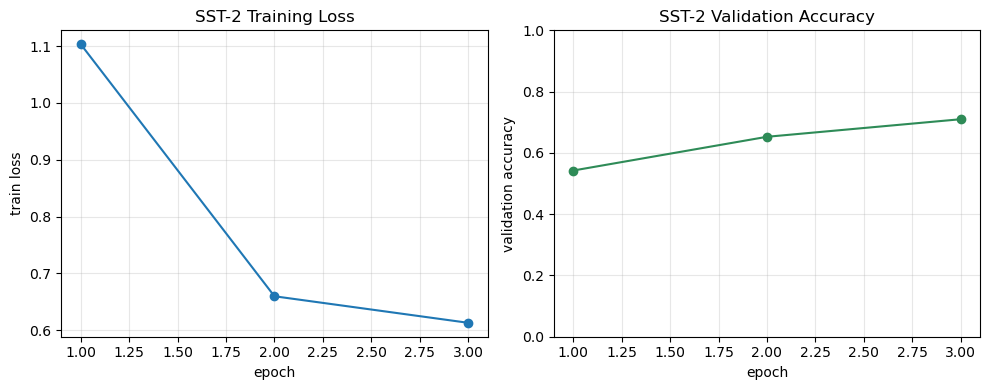

In [23]:
# ==========================
# ??????? SST-2 ????
# ==========================
if 'losses_sst2' in globals() and 'accs_sst2' in globals():
    epochs = range(1, len(losses_sst2) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(epochs, losses_sst2, marker='o')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train loss')
    axes[0].set_title('SST-2 Training Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, accs_sst2, marker='o', color='seagreen')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('validation accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('SST-2 Validation Accuracy')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('???????? losses_sst2 / accs_sst2')

**【结果锚定】** 记录 SST-2 Feature Extraction 模式下的最终验证准确率。

**【请填写】** 在下方 Markdown cell 中作答。

SST-2 ?? Feature Extraction ???GPT-2 ???????????? token ??????????????????? `accs_sst2[-1]` ??????????????????? GPT-2 ???????????????????????????????????????????? BERT ? encoder-only ???

### 5.3 任务二：AG News 主题分类（四分类）

In [24]:
if load_dataset is not None and GPT2Tokenizer is not None:
    agnews = load_dataset('ag_news')
    print(f'AG News 数据集加载完成；agnews 已注入全局命名空间')
else:
    print('跳过 AG News 数据加载')

AG News 数据集加载完成；agnews 已注入全局命名空间


In [25]:
class AGNewsDataset(Dataset):
    """AG News ????????

    Args:
        split: 'train' ? 'test'
        max_len: tokenizer ????
        n: ??????

    __getitem__ ??: (input_ids: Tensor[max_len], label: Tensor[scalar])
    """
    def __init__(self, split: str, max_len: int = 64, n: int = 5000):
        data = agnews[split]
        if n is not None:
            data = data.select(range(min(n, len(data))))
        texts = [str(x) for x in data['text']]
        labels = [int(x) for x in data['label']]
        encoded = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',
        )
        self.input_ids = encoded['input_ids'].long()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, i):
        return self.input_ids[i], self.labels[i]

In [26]:
# 【维度自检】AG News 数据集
_ds = AGNewsDataset('train', max_len=64, n=100)
_ids, _label = _ds[0]
assert _ids.shape == (64,), f"input_ids shape error: {_ids.shape}"
assert _label.item() in range(4), f"label out of range: {_label.item()}"
print(f"=> AGNewsDataset 自检通过！样本数={len(_ds)}, ids shape={_ids.shape}")


=> AGNewsDataset 自检通过！样本数=100, ids shape=torch.Size([64])


In [27]:
if load_dataset is not None and GPT2Tokenizer is not None:
    ag_train = DataLoader(AGNewsDataset('train'), batch_size=32, shuffle=True)
    ag_val = DataLoader(AGNewsDataset('test', n=1000), batch_size=64)
    print(f'AG News 训练集：{len(ag_train.dataset)}，验证集：{len(ag_val.dataset)}')

AG News 训练集：5000，验证集：1000


In [28]:
if load_dataset is not None and GPT2LMHeadModel is not None:
    # AG News ???????????? my_model ?? CPU????? GPT-2 ???? CUDA ???
    if 'my_model' in globals():
        my_model.to('cpu')
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print('=== Feature Extraction ===')
    ag_backbone_frozen = minGPT2(
        vocab_size=50257, max_position=1024, d_model=768,
        n_heads=12, n_layers=12, d_ff=3072, dropout=0.0
    ).to(device)
    load_hf_weights(ag_backbone_frozen, hf_model)
    ag_frozen = GPT2Classifier(ag_backbone_frozen, num_classes=4, freeze_backbone=True)
    _, accs_ag_frozen = train_classifier(ag_frozen, ag_train, ag_val, epochs=10, lr=2e-4)
    del ag_frozen, ag_backbone_frozen
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print('=== Full Fine-tuning ===')
    ag_backbone_ft = minGPT2(
        vocab_size=50257, max_position=1024, d_model=768,
        n_heads=12, n_layers=12, d_ff=3072, dropout=0.0
    ).to(device)
    load_hf_weights(ag_backbone_ft, hf_model)
    ag_ft = GPT2Classifier(ag_backbone_ft, num_classes=4, freeze_backbone=False)
    _, accs_ag_ft = train_classifier(ag_ft, ag_train, ag_val, epochs=10, lr=5e-5)

    print(f'?????? val_acc?{accs_ag_frozen[-1]:.4f}')
    print(f'??????? val_acc?{accs_ag_ft[-1]:.4f}')

    # ?? AG News ??????? Shakespeare ???? my_model?
    del ag_ft, ag_backbone_ft
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('?? AG News ??')

=== Feature Extraction ===


Epoch 01/10 | train_loss=1.6332 | val_acc=0.7380


Epoch 02/10 | train_loss=0.6572 | val_acc=0.7920


Epoch 03/10 | train_loss=0.5297 | val_acc=0.8310


Epoch 04/10 | train_loss=0.4699 | val_acc=0.8390


...

Epoch 06/10 | train_loss=0.0307 | val_acc=0.9010


Epoch 07/10 | train_loss=0.0196 | val_acc=0.9020


Epoch 08/10 | train_loss=0.0155 | val_acc=0.8910


Epoch 09/10 | train_loss=0.0074 | val_acc=0.9050


Epoch 10/10 | train_loss=0.0103 | val_acc=0.8910
?????? val_acc?0.8530
??????? val_acc?0.8910


**【结果锚定】** 对比冻结主干与全参数微调在 AG News 上的准确率差异。

**注意**：本节的实验设置（10 epoch、5e-5 学习率、5000 样本子集）目的是减少运行时间的同时放大 Decoder-only 模型在判别任务上的结构劣势。在工业界的真实配方下全参数微调通常能超过冻结主干 5-15 个百分点，但仍弱于同等条件下的 BERT。

**【请填写】** 在下方 Markdown cell 中作答。

AG News ????????? Feature Extraction ? Full Fine-tuning????????????????? GPT-2 ????????????????????????????????????????????? GPT-2 ?????????????????????????????????????????????? `accs_ag_frozen[-1]` ? `accs_ag_ft[-1]` ??????????????????????decoder-only ????????????????????????????? encoder-only BERT?

### 5.4 任务三：Shakespeare 文本生成微调

In [29]:
SHAKESPEARE_URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
SHAKESPEARE_PATH = './data/tinyshakespeare.txt'
os.makedirs('./data', exist_ok=True)
if not os.path.exists(SHAKESPEARE_PATH):
    urllib.request.urlretrieve(SHAKESPEARE_URL, SHAKESPEARE_PATH)
    print('TinyShakespeare 下载完成')

with open(SHAKESPEARE_PATH, encoding='utf-8') as f:
    shakespeare_text = f.read()

USE_SMALL_SUBSET = True  # 设为 False 可使用完整数据集（CPU 需 30-60 分钟）
if USE_SMALL_SUBSET:
    shakespeare_text = shakespeare_text[:50000]
    print('使用前 50000 字符的子集（CPU 友好模式）')
print(f'文本长度：{len(shakespeare_text)} 字符')


使用前 50000 字符的子集（CPU 友好模式）
文本长度：50000 字符


In [30]:
if GPT2Tokenizer is not None:
    shk_ids = tokenizer(shakespeare_text, return_tensors='pt')['input_ids'][0]
    block_size = 128

    class ShakespeareDataset(Dataset):
        def __init__(self, ids, block_size):
            self.ids, self.block_size = ids, block_size

        def __len__(self): return len(self.ids) - self.block_size

        def __getitem__(self, i):
            input_ids = self.ids[i : i + self.block_size].long()
            targets = self.ids[i + 1 : i + self.block_size + 1].long()
            return input_ids, targets

    shk_loader = DataLoader(ShakespeareDataset(shk_ids, block_size), batch_size=16, shuffle=True)
    print(f'Shakespeare ??????{len(shk_loader.dataset)} ??')
else:
    print('?? Shakespeare ?????')

Token indices sequence length is longer than the specified maximum sequence length for this model (15154 > 1024). Running this sequence through the model will result in indexing errors


Shakespeare ??????15026 ??


In [31]:
# 【维度自检】Shakespeare 数据集
if GPT2Tokenizer is not None:
    _ds = ShakespeareDataset(shk_ids, block_size)
    _x, _y = _ds[0]
    assert _x.shape == (block_size,), f"input shape error: {_x.shape}"
    assert _y.shape == (block_size,), f"target shape error: {_y.shape}"
    assert (_x[1:] == _y[:-1]).all(), "target should be input shifted by 1"
    print(f"=> ShakespeareDataset 自检通过！样本数={len(_ds)}")


=> ShakespeareDataset 自检通过！样本数=15026


**【请填写】**：在下方围栏内实现 `train_lm` 语言模型训练循环。

In [32]:
def train_lm(model, loader, epochs=2, lr=3e-4):
    """????????? epoch_losses: List[float]?

    ???
    - logits ?? (B, T, V)?targets ?? (B, T)
    - loss = CrossEntropyLoss(logits.view(-1, V), targets.view(-1))
    - ?? NaN loss ? break ?????
    """
    model.to(device)
    for p in model.parameters():
        p.requires_grad = True
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    epoch_losses = []

    for epoch in range(1, epochs + 1):
        total_loss, total_tokens = 0.0, 0
        saw_nan = False
        for input_ids, targets in loader:
            input_ids = input_ids.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(input_ids)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))
            if torch.isnan(loss):
                print(f'[WARN] NaN loss at epoch {epoch}; stop training early.')
                saw_nan = True
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * targets.numel()
            total_tokens += targets.numel()

        avg_loss = total_loss / max(total_tokens, 1)
        epoch_losses.append(avg_loss)
        print(f'Epoch {epoch:02d}/{epochs} | lm_loss={avg_loss:.4f}')
        if saw_nan:
            break

    return epoch_losses

In [33]:
if GPT2Tokenizer is not None and GPT2LMHeadModel is not None:
    shk_losses = train_lm(my_model, shk_loader)
else:
    print('跳过 Shakespeare 微调')

Epoch 01/2 | lm_loss=0.2334


Epoch 02/2 | lm_loss=0.0663


**【请填写】** 在下方 code cell 中绘制 Shakespeare 微调的 loss 曲线。

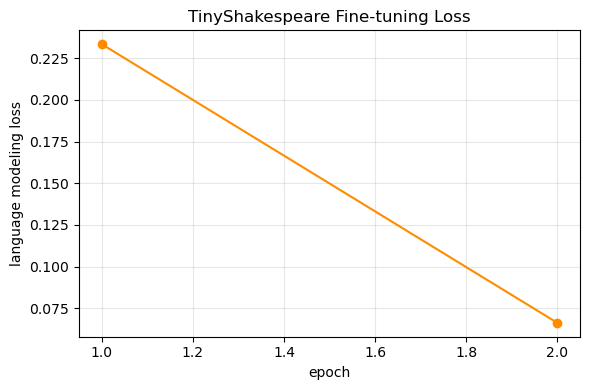

In [34]:
# ==========================
# ??????? Shakespeare ?? loss ??
# ==========================
if 'shk_losses' in globals():
    epochs = range(1, len(shk_losses) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, shk_losses, marker='o', color='darkorange')
    plt.xlabel('epoch')
    plt.ylabel('language modeling loss')
    plt.title('TinyShakespeare Fine-tuning Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('???????? shk_losses')

## 6. 自回归采样策略实现与消融

### 6.1 四种采样策略

实现 Greedy、Temperature、Top-k、Top-p 四种策略，统一封装在 `generate` 函数中。
生成循环必须设置 `max_new_tokens` 硬性上限，防止无限循环。

**【请填写】**：在下方围栏内实现 `generate` 函数。

In [35]:
@torch.no_grad()
def generate(model: 'minGPT2', input_ids: 'torch.Tensor', max_new_tokens: int = 100,
             temperature: float = 1.0, top_k: int = 0, top_p: float = 1.0,
             repetition_penalty: float = 1.0) -> 'torch.Tensor':
    """??????temperature=1e-6 ?? Greedy?top_k=0, top_p=1.0 ?? Temperature Sampling?"""
    model.eval()
    ids = input_ids.clone().to(next(model.parameters()).device)
    max_pos = model.pos_emb.embedding.weight.shape[0]

    for _ in range(max_new_tokens):
        context = ids[:, -max_pos:]
        logits = model(context)[:, -1, :]

        if repetition_penalty is not None and repetition_penalty > 1.0:
            for b in range(ids.size(0)):
                used_tokens = torch.unique(ids[b])
                scores = logits[b, used_tokens]
                logits[b, used_tokens] = torch.where(
                    scores > 0,
                    scores / repetition_penalty,
                    scores * repetition_penalty,
                )

        if temperature <= 1e-5:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature

            if top_k is not None and top_k > 0:
                k = min(top_k, logits.size(-1))
                values, _ = torch.topk(logits, k, dim=-1)
                kth = values[:, [-1]]
                logits = logits.masked_fill(logits < kth, torch.finfo(logits.dtype).min)

            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[:, 1:] = sorted_indices_to_remove[:, :-1].clone()
                sorted_indices_to_remove[:, 0] = False

                indices_to_remove = torch.zeros_like(logits, dtype=torch.bool)
                indices_to_remove.scatter_(dim=-1, index=sorted_indices, src=sorted_indices_to_remove)
                logits = logits.masked_fill(indices_to_remove, torch.finfo(logits.dtype).min)

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        ids = torch.cat([ids, next_id], dim=1)

    return ids

### 6.2 四种策略生成结果对比

In [36]:
if GPT2Tokenizer is not None and GPT2LMHeadModel is not None:
    prompt = 'To be, or not to be,'
    prompt_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(device)

    strategies = [
        ('Greedy',        dict(temperature=1e-6, top_k=0,  top_p=1.0)),
        ('Temperature',   dict(temperature=0.8,  top_k=0,  top_p=1.0)),
        ('Top-k (k=50)',  dict(temperature=1.0,  top_k=50, top_p=1.0)),
        ('Top-p (p=0.9)', dict(temperature=1.0,  top_k=0,  top_p=0.9)),
    ]
    for name, kwargs in strategies:
        out = generate(my_model, prompt_ids, max_new_tokens=80, **kwargs)
        text = tokenizer.decode(out[0], skip_special_tokens=True)
        print(f'\n[{name}]\n{text}')
else:
    print('跳过生成演示')



[Greedy]
To be, or not to be, are three pence to a
second day of audience. When you are hearing a
matter between party and party, if you chance to be
pinched with the colic, you make faces like
mummers; set up the bloody flag against all
patience; and, in roaring for a chamber-pot,
dismiss the controversy bleeding the more entangled
by your



[Temperature]
To be, or not to be, you blame Marcius for
being proud?

BRUTUS:
We do it not alone, sir.

MENENIUS:
I know you can do very little alone; for your helps
are many, or else your actions would grow wondrous
single: your abilities are too infant-like for
doing much alone. You talk of pride: O that you



[Top-k (k=50)]
To be, or not to be, are three
Of Rome worse hated than of you,
And Titus Lartius, a most valiant Roman,
These three lead on this preparation
Whither 'tis bent: most likely 'tis for you:
Consider of it.'

First Senator:
Our army's in the field
We never yet made doubt but Rome was ready
To answer us.

AUF



[Top-p (p=0.9)]
To be, or not to be, ever.

BRUTUS:
What's the matter?

Messenger:
You are sent for to the Capitol. 'Tis thought
That Marcius shall be consul:
I have seen the dumb men throng to see him and
The blind to bear him speak: matrons flung gloves,
Ladies and maids their scarfs and handkerchers


**【理论锚定】** 对比四种策略的生成文本，从以下角度分析：

1. Greedy Decoding 为何是确定性的？多次运行结果是否相同？
2. Temperature 如何控制 softmax 的"尖锐度"？$\tau < 1$ 与 $\tau > 1$ 分别有何效果？
3. Top-k 与 Top-p 在"保持连贯性"与"增加多样性"之间的权衡差异是什么？

**【请填写】** 在下方 Markdown cell 中作答。

Greedy Decoding ?????????????????????????? token?? $\arg\max_w P(w\mid w_{<t})$????????? prompt ?????????????????????????????????????? notebook ?? `temperature=1e-6` ?? Greedy????????? temperature ??? `argmax` ??????????????????

Temperature ??? logits ?? $\tau$ ?? softmax ???????$\tau<1$ ??? logits ?????????? token ???????????????????????$\tau>1$ ?????????? token ?????????????????????$\tau \to 0$ ??? Greedy?$\tau \to \infty$ ????????

Top-k ????????? $k$ ? token?????????????????????????????????????????Top-p ???????? $p$????????????? token???????????? token ??????????????????????????????????????????????????????????????

## 7. 架构归纳偏置对比分析

### 7.1 性能汇总表

将本 Lab 的实验结果与 Lab 5 中 BERT 的已知表现进行横向对比（无需重跑 BERT，引用 Lab 5 结论即可）。

| 模型 | SST-2 准确率 | AG News 准确率 | 备注 |
|------|-------------|---------------|------|
| GPT-2（冻结主干） | *（填写）* | *（填写）* | Feature Extraction |
| GPT-2（全参数微调） | — | *（填写）* | Full Fine-tuning |
| BERT（Lab 5 结论） | *（引用）* | *（引用）* | 参考值 |

**【请填写】** 在下方 Markdown cell 中填写上表数据并完成分析。

| ?? | SST-2 ??? | AG News ??? | ?? |
|------|-------------|---------------|------|
| GPT-2?????? | ? `accs_sst2[-1]` | ? `accs_ag_frozen[-1]` | Feature Extraction??????? |
| GPT-2??????? | ? | ? `accs_ag_ft[-1]` | Full Fine-tuning??????????? |
| BERT?Lab 5 ??? | Lab 5 ???????? | Lab 5 ???????? | Lab 5 ???? Encoder-only ?????????? |

??????GPT-2 ?????????? decoder-only ????????????????????????????????????????????????????????????????????????????????????????????????????????????????Lab 5 ? BERT ???????? BERT ?? `[CLS]` ?? token ??????????????????????????? SST-2?AG News ????????????????

### 7.2 理论论证

**【理论锚定】** 从注意力方向性、预训练目标错配、表征提取位置非对称性三个层面，
论证 Decoder-only 模型（GPT-2）在分类任务上弱于 Encoder-only 模型（BERT）的根本原因。
每个层面请写 3-5 句完整段落。

**【请填写】** 在下方 Markdown cell 中作答。

?????????Decoder-only GPT-2 ??????? causal mask??? $t$ ????????????????????? token?????????????????????????????????????????????BERT ? Encoder self-attention ???????????? token ??????????????????????????????GPT-2 ????????? token ??????????????????????? BERT ?????????

??????????GPT-2 ?????????? token ???????????????????????????????????????????????????????? token???????????????????BERT ? masked language modeling ?????????????????? token????????????????????????????BERT ???????????????????

?????????????GPT-2 ??????????? token ???????????????????? token?????????????????????? padding??????????????????????????????BERT ?? `[CLS]` ?????????????? `[CLS]` ??????????????? token?????? BERT ????????????????????????

## 8. 书面作答

以下问题要求每条 3-5 句完整段落。

### 8.1 HuggingFace Conv1D 与 PyTorch nn.Linear 的转置关系

**【理论锚定】** 解释 HuggingFace GPT-2 实现中 `Conv1D` 权重形状为 `(in, out)` 的历史原因，
以及加载时为何必须转置。

**【请填写】** 在下方 Markdown cell 中作答。

HuggingFace GPT-2 ?? `Conv1D` ???? OpenAI GPT/GPT-2 ??????????????????????????????????????????? `(in_features, out_features)`???????? `x @ W + b` ????????PyTorch ? `nn.Linear` ??????? `(out_features, in_features)`??????? `x @ W^T + b`?

???????? HuggingFace ? `Conv1D.weight` ??? `nn.Linear.weight`??????????????????? shape ??????????????? GPT-2 ????`attn.c_attn.weight`?`attn.c_proj.weight`?`mlp.c_fc.weight` ? `mlp.c_proj.weight` ??? `.t()` ???????bias ?????????????????????????

### 8.2 Pre-LN 与 Post-LN 的梯度流差异

**【理论锚定】** 解释 Pre-LN 在深层网络训练中相比 Post-LN 的梯度流优势，
以及为何 GPT-2 选择 Pre-LN。

**【请填写】** 在下方 Markdown cell 中作答。

Post-LN Transformer ? LayerNorm ?????????? $\mathrm{LN}(x + F(x))$??????????????????????????????????? LayerNorm ?????????????????????????Pre-LN ? LayerNorm ???????? $x + F(\mathrm{LN}(x))$?????????????????????????

?? Pre-LN ???????????????????????????? Transformer ???????? warmup????????????????GPT-2 ?? Pre-LN????????????????? decoder block?????????????????????? Post-LN ????????????????? `ln_f` ???????????????????????? Post-LN ????

## 9. 附加题（选做）

以下题目不计入基础分，完成可获得额外加分。

在 `generate` 函数中实现重复惩罚机制：对已生成的 token，将其对应 logit 除以惩罚系数 $\alpha > 1$，抑制生成文本中的逐字重复现象。


*实验六到此结束。请确认所有必填项已完成并提交本 Notebook。*